# Object Detection Solution
52-class detection, AP@0.5 metric
All seeds fixed to 993

## 1. Setup & Imports

In [1]:
!pip install ultralytics ensemble-boxes -q

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from ensemble_boxes import weighted_boxes_fusion
import yaml
import shutil
import cv2
import torch

from ultralytics import YOLO

SEED = 993
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
torch.manual_seed(SEED)

print('Setup complete')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup complete
GPU: Tesla T4


## 2. Paths & Config

In [ ]:
from pathlib import Path

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
LOCAL_ROOT = Path(".")
WORKING_DIR = Path("/kaggle/working") if KAGGLE_INPUT_ROOT.exists() else LOCAL_ROOT

EXPECTED_STRUCTURES = [
    {
        "train_images": Path("train/train/images"),
        "train_labels": Path("train/train/labels"),
        "test_images": Path("test/test/images"),
        "sample_submission": Path("sample_submission.csv"),
    },
    {
        "train_images": Path("train/images"),
        "train_labels": Path("train/labels"),
        "test_images": Path("test/images"),
        "sample_submission": Path("sample_submission.csv"),
    },
    {
        "train_images": Path("train/images"),
        "train_labels": Path("train/labels"),
        "test_images": Path("test"),
        "sample_submission": Path("sample_submission.csv"),
    },
]

def looks_like_competition_dataset(root: Path, structure: dict) -> bool:
    return all((root / rel_path).exists() for rel_path in structure.values())

def find_dataset_root():
    search_roots = []

    if KAGGLE_INPUT_ROOT.exists():
        search_roots.append(KAGGLE_INPUT_ROOT)
        search_roots.extend([p for p in KAGGLE_INPUT_ROOT.rglob("*") if p.is_dir()])

    search_roots.append(LOCAL_ROOT)

    candidates = []

    for root in search_roots:
        for structure in EXPECTED_STRUCTURES:
            if looks_like_competition_dataset(root, structure):
                candidates.append((root, structure))

    if not candidates:
        raise FileNotFoundError(
            "Не удалось найти датасет. Ожидается одна из структур: "
            "train/train/images + train/train/labels + test/test/images, "
            "или train/images + train/labels + test/images."
        )

    candidates = sorted(candidates, key=lambda x: len(str(x[0])))
    return candidates[0]

INPUT_DIR, STRUCTURE = find_dataset_root()

BASE_DIR = WORKING_DIR

TRAIN_IMAGES = INPUT_DIR / STRUCTURE["train_images"]
TRAIN_LABELS = INPUT_DIR / STRUCTURE["train_labels"]
TEST_IMAGES = INPUT_DIR / STRUCTURE["test_images"]
SAMPLE_SUB = INPUT_DIR / STRUCTURE["sample_submission"]

RUN_DIR = BASE_DIR / "runs"
IMGSZ = 960

print(f"INPUT_DIR: {INPUT_DIR}")
print(f"WORKING_DIR: {WORKING_DIR}")
print(f"Train images: {len(list(TRAIN_IMAGES.glob('*.jpg')))} files")
print(f"Train labels: {len(list(TRAIN_LABELS.glob('*.txt')))} files")
print(f"Test images: {len(list(TEST_IMAGES.glob('*.jpg')))} files")

TRAIN_IMAGES: /kaggle/input/datasets/shvarev/pipiska/train/train/images True
TRAIN_LABELS: /kaggle/input/datasets/shvarev/pipiska/train/train/labels True
TEST_IMAGES:  /kaggle/input/datasets/shvarev/pipiska/test/test/images True
SAMPLE_SUB:   /kaggle/input/datasets/shvarev/pipiska/sample_submission.csv True
Train images: 1697 files
Train labels: 1697 files
Test  images: 424 files


## 3. EDA

Total annotations: 10498
Unique classes:    52
Class IDs range:   0 - 51


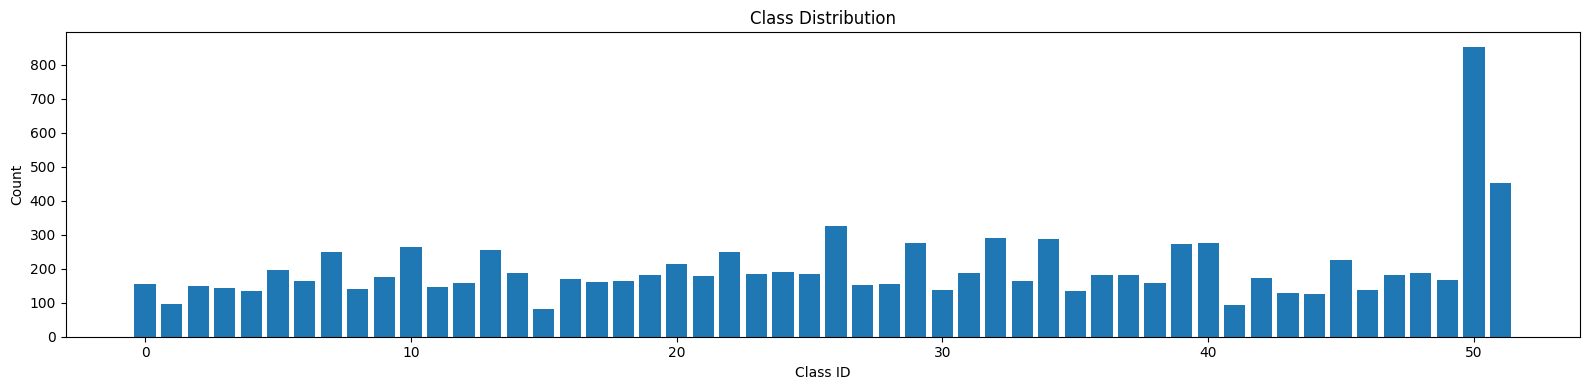

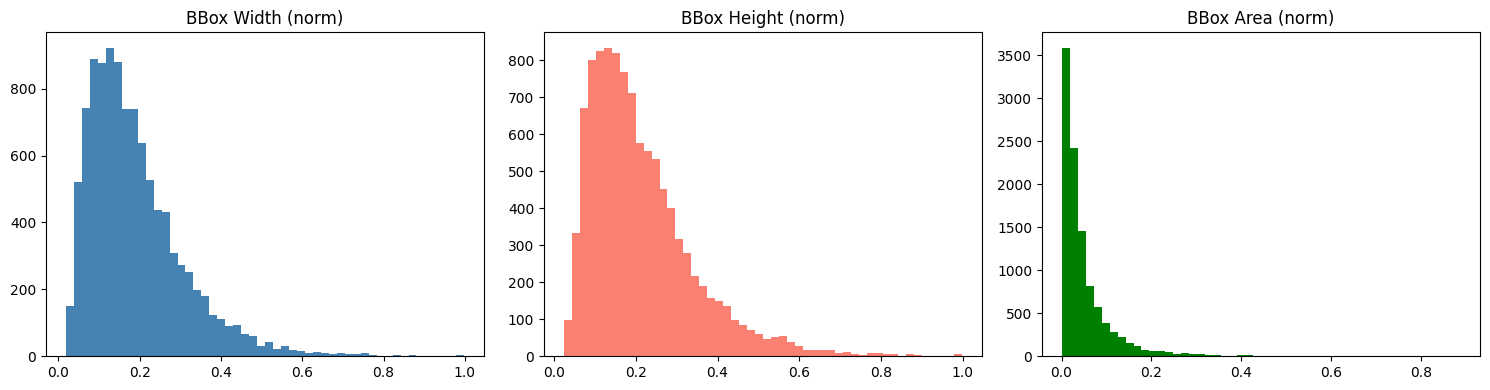

Avg bbox: 0.190 x 0.213
Median area: 0.02948

Редкие классы (< 50 примеров):
[]


In [3]:
all_classes = []
all_widths, all_heights, all_areas = [], [], []

for lf in TRAIN_LABELS.glob('*.txt'):
    for line in lf.read_text().strip().split('\n'):
        if not line.strip(): continue
        parts = line.split()
        all_classes.append(int(parts[0]))
        w, h = float(parts[3]), float(parts[4])
        all_widths.append(w); all_heights.append(h); all_areas.append(w * h)

print(f'Total annotations: {len(all_classes)}')
print(f'Unique classes:    {len(set(all_classes))}')
print(f'Class IDs range:   {min(all_classes)} - {max(all_classes)}')

class_counts = Counter(all_classes)
plt.figure(figsize=(16, 4))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel('Class ID'); plt.ylabel('Count'); plt.title('Class Distribution')
plt.tight_layout()
plt.savefig('/kaggle/working/eda_class_distribution.png', dpi=100)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(all_widths,  bins=50, color='steelblue'); axes[0].set_title('BBox Width (norm)')
axes[1].hist(all_heights, bins=50, color='salmon');    axes[1].set_title('BBox Height (norm)')
axes[2].hist(all_areas,   bins=50, color='green');     axes[2].set_title('BBox Area (norm)')
plt.tight_layout()
plt.savefig('/kaggle/working/eda_bbox_distribution.png', dpi=100)
plt.show()

print(f'Avg bbox: {np.mean(all_widths):.3f} x {np.mean(all_heights):.3f}')
print(f'Median area: {np.median(all_areas):.5f}')
print('\nРедкие классы (< 50 примеров):')
rare = {k: v for k, v in class_counts.items() if v < 50}
print(sorted(rare.items(), key=lambda x: x[1]))

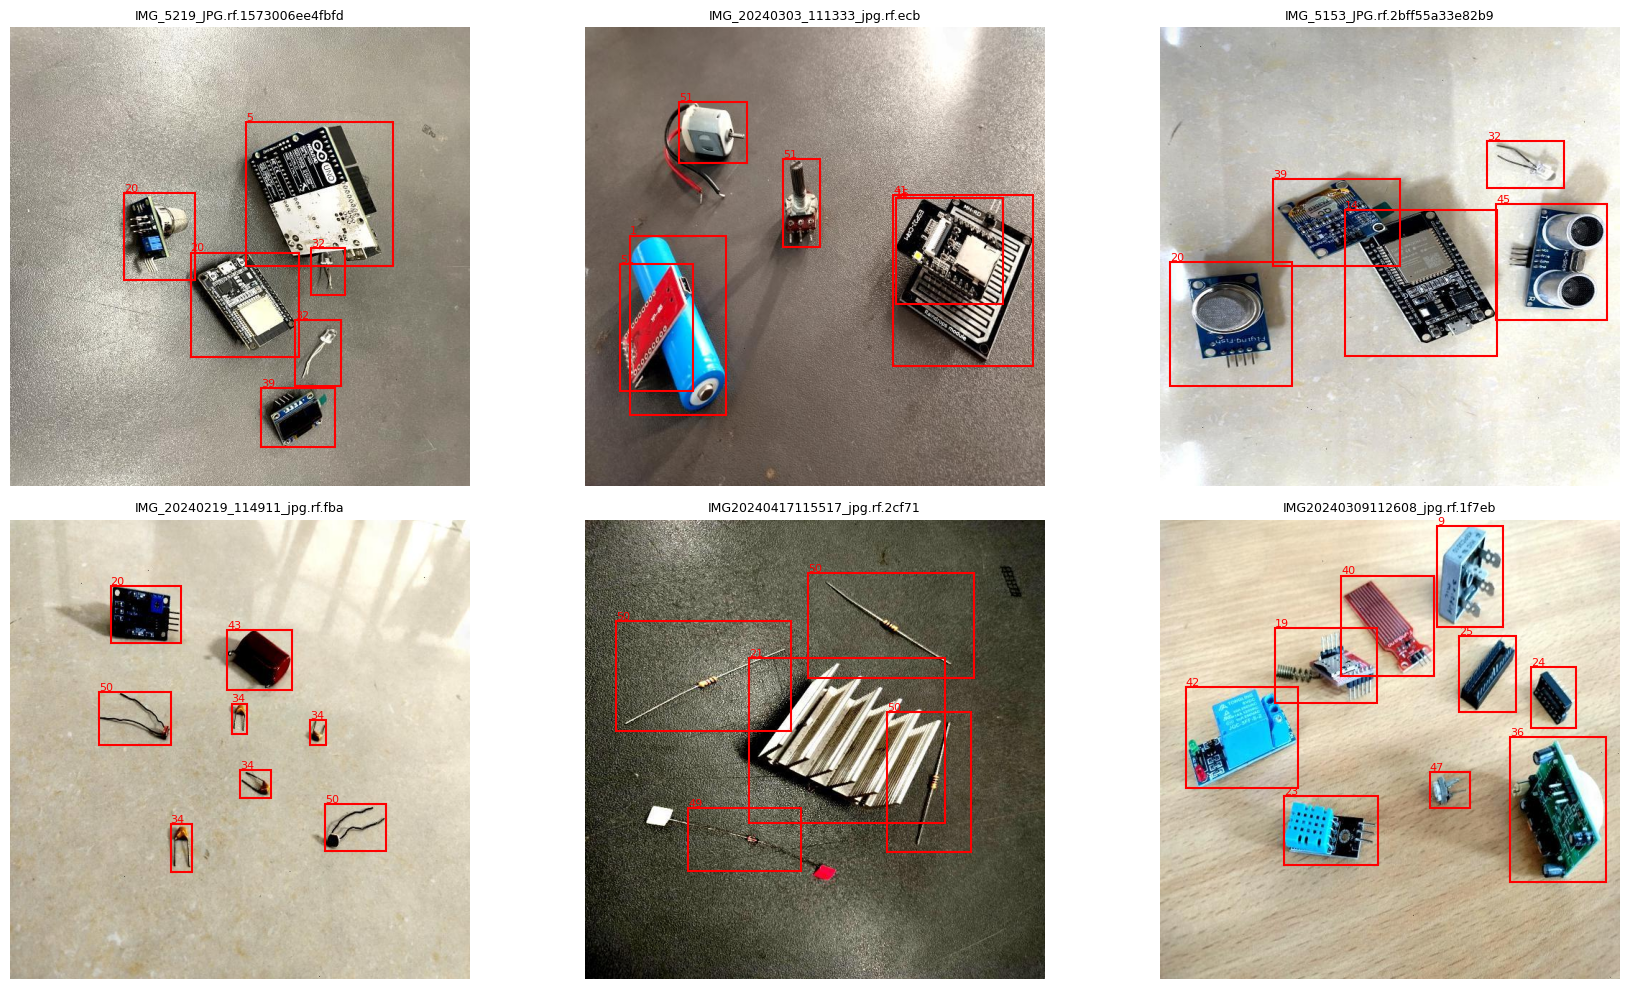

In [4]:
sample_imgs = random.sample(list(TRAIN_IMAGES.glob('*.jpg')), 6)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, img_path in enumerate(sample_imgs):
    img = Image.open(img_path)
    W, H = img.size
    ax = axes[i]; ax.imshow(img)
    lbl_path = TRAIN_LABELS / (img_path.stem + '.txt')
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().split('\n'):
            if not line.strip(): continue
            cls, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw/2) * W; y1 = (cy - bh/2) * H
            rect = patches.Rectangle((x1, y1), bw*W, bh*H, linewidth=1.5, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-3, str(int(cls)), color='red', fontsize=8)
    ax.set_title(img_path.name[:30], fontsize=9); ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/eda_sample_images.png', dpi=100)
plt.show()

## 4. Train/Val Split & Dataset Config

In [5]:
NUM_CLASSES = max(all_classes) + 1
CLASS_NAMES = [str(i) for i in range(NUM_CLASSES)]

all_stems = [f.stem for f in TRAIN_IMAGES.glob('*.jpg')]
train_stems, val_stems = train_test_split(all_stems, test_size=0.2, random_state=SEED)
print(f'Train: {len(train_stems)}, Val: {len(val_stems)}')

SPLIT_DIR = Path('/kaggle/working/dataset_split')
for split in ['train', 'val']:
    (SPLIT_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (SPLIT_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

def copy_split(stems, split):
    for stem in stems:
        img_src = TRAIN_IMAGES / f'{stem}.jpg'
        lbl_src = TRAIN_LABELS / f'{stem}.txt'
        img_dst = SPLIT_DIR / split / 'images' / f'{stem}.jpg'
        lbl_dst = SPLIT_DIR / split / 'labels' / f'{stem}.txt'
        if not img_dst.exists(): shutil.copy2(img_src, img_dst)
        if lbl_src.exists() and not lbl_dst.exists(): shutil.copy2(lbl_src, lbl_dst)

copy_split(train_stems, 'train')
copy_split(val_stems, 'val')
print('Split done!')

dataset_yaml = {
    'path': str(SPLIT_DIR.resolve()),
    'train': 'train/images',
    'val':   'val/images',
    'nc': NUM_CLASSES,
    'names': CLASS_NAMES
}
yaml_path = Path('/kaggle/working/dataset.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print(f'Dataset yaml written, nc={NUM_CLASSES}')
print(yaml_path.read_text())

Train: 1357, Val: 340
Split done!
Dataset yaml written, nc=52
names:
- '0'
- '1'
- '2'
- '3'
- '4'
- '5'
- '6'
- '7'
- '8'
- '9'
- '10'
- '11'
- '12'
- '13'
- '14'
- '15'
- '16'
- '17'
- '18'
- '19'
- '20'
- '21'
- '22'
- '23'
- '24'
- '25'
- '26'
- '27'
- '28'
- '29'
- '30'
- '31'
- '32'
- '33'
- '34'
- '35'
- '36'
- '37'
- '38'
- '39'
- '40'
- '41'
- '42'
- '43'
- '44'
- '45'
- '46'
- '47'
- '48'
- '49'
- '50'
- '51'
nc: 52
path: /kaggle/working/dataset_split
train: train/images
val: val/images



## 5. Train YOLOv11x

In [ ]:
torch.cuda.empty_cache()
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

model = YOLO('yolo11x.pt')

results = model.train(
    data=str(yaml_path),
    epochs=120,
    imgsz=IMGSZ,
    batch=4,
    workers=4,
    seed=SEED,
    deterministic=True,
    project=str(RUN_DIR),
    name='yolo11x_det',
    exist_ok=True,
    # Augmentations
    mosaic=1.0,
    close_mosaic=15,
    mixup=0.15,
    copy_paste=0.3,
    degrees=15.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    flipud=0.3,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    # Optimizer
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=5,
    cos_lr=True,
    label_smoothing=0.1,
    patience=40,
    save=True,
    save_period=10,
)

print('Training finished!')

shutil.copy2(RUN_DIR / 'yolo11x_det' / 'weights' / 'best.pt', '/kaggle/working/best.pt')
shutil.copy2(RUN_DIR / 'yolo11x_det' / 'weights' / 'last.pt', '/kaggle/working/last.pt')
print('Веса сохранены: /kaggle/working/best.pt')

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.43 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11x_det, nbs=64, nms=Fa

## 6. Load Best Weights & Validate

In [ ]:
best_weights = RUN_DIR / 'yolo11x_det' / 'weights' / 'best.pt'
if not best_weights.exists():
    print('Веса не найдены в runs, загружаю из Output...')
    best_weights = Path('/kaggle/working/best.pt')
print(f'Best weights: {best_weights}, exists: {best_weights.exists()}')

model_best = YOLO(str(best_weights))

val_results = model_best.val(
    data=str(yaml_path),
    imgsz=IMGSZ,
    batch=4,
    iou=0.5,
    conf=0.001,
    rect=True,
    seed=SEED,
)

print(f'\nmAP@0.5:      {val_results.box.map50:.4f}')
print(f'mAP@0.5:0.95: {val_results.box.map:.4f}')

Best weights: /kaggle/working/runs/yolo11x_det/weights/best.pt, exists: True
Ultralytics 8.4.43 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11x summary (fused): 191 layers, 56,887,084 parameters, 0 gradients, 194.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1526.2±391.3 MB/s, size: 61.9 KB)
val: Scanning /kaggle/working/dataset_split/val/labels.cache... 340 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 340/340 129.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 85/85 1.3it/s 1:03
                   all        340       2056      0.863      0.859      0.843      0.556
                     0         25         26      0.893      0.846      0.843      0.503
                     1         19         19      0.939      0.789      0.886       0.67
                     2         34         34      0.892      0.732      0.728      0.469
                     3         25         2

## 7. Inference on Test Set

In [ ]:
test_images = sorted(list(TEST_IMAGES.glob('*.jpg')))
print(f'Test images: {len(test_images)}')

torch.backends.cudnn.deterministic = False

predictions = model_best.predict(
    source=str(TEST_IMAGES),
    imgsz=IMGSZ,
    conf=0.001,
    iou=0.45,
    max_det=300,
    augment=True,
    verbose=False,
    stream=True,
)

pred_dict = {}
for result in predictions:
    img_name = Path(result.path).name
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        pred_dict[img_name] = None
        continue
    H, W = result.orig_shape
    xyxy    = boxes.xyxy.cpu().numpy()
    confs   = boxes.conf.cpu().numpy()
    cls_ids = boxes.cls.cpu().numpy().astype(int)
    pred_dict[img_name] = (cls_ids, xyxy, confs, W, H)

print(f'Inference done: {len(pred_dict)} images')
print(f'With detections: {sum(1 for v in pred_dict.values() if v is not None)}')

Test images: 424
Inference done: 424 images
With detections: 424


## 8. WBF Postprocessing & Build Submission

In [9]:
def apply_wbf(xyxy, confs, cls_ids, W, H, iou_thr=0.5, skip_box_thr=0.001):
    boxes_norm = xyxy.copy().astype(float)
    boxes_norm[:, [0, 2]] /= W
    boxes_norm[:, [1, 3]] /= H
    boxes_norm = np.clip(boxes_norm, 0, 1)
    boxes_wbf, scores_wbf, labels_wbf = weighted_boxes_fusion(
        [boxes_norm.tolist()],
        [confs.tolist()],
        [cls_ids.tolist()],
        iou_thr=iou_thr,
        skip_box_thr=skip_box_thr,
    )
    boxes_wbf = np.array(boxes_wbf)
    boxes_wbf[:, [0, 2]] *= W
    boxes_wbf[:, [1, 3]] *= H
    return np.array(labels_wbf, dtype=int), boxes_wbf, np.array(scores_wbf)


def build_prediction_string(cls_ids, xyxy, confs):
    parts = []
    for i in range(len(cls_ids)):
        x1, y1, x2, y2 = xyxy[i]
        parts.append(
            f"{int(cls_ids[i])} {float(confs[i]):.4f} "
            f"{int(round(x1))} {int(round(y1))} "
            f"{int(round(x2))} {int(round(y2))}"
        )
    return ' '.join(parts)


df_sub = pd.read_csv(SAMPLE_SUB)
prediction_strings = []
image_ids = []

for _, row in df_sub.iterrows():
    img_id = row['image_id']
    key = None
    for k in pred_dict.keys():
        if Path(k).stem == Path(str(img_id)).stem or k == img_id or k == img_id + '.jpg':
            key = k; break

    image_ids.append(img_id)
    if key is None or pred_dict.get(key) is None:
        prediction_strings.append(None)
    else:
        cls_ids, xyxy, confs, W, H = pred_dict[key]
        cls_ids_wbf, xyxy_wbf, confs_wbf = apply_wbf(xyxy, confs, cls_ids, W, H)
        pred_str = build_prediction_string(cls_ids_wbf, xyxy_wbf, confs_wbf)
        prediction_strings.append(pred_str if pred_str else None)

df_result = pd.DataFrame({'image_id': image_ids, 'PredictionString': prediction_strings})
print(f'Submission built: {len(df_result)} rows')
print(f'Non-null: {df_result.PredictionString.notna().sum()}')
print(df_result.head(3))

Submission built: 424 rows
Non-null: 424
                                            image_id  \
0  IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1a...   
1  IMG20240228122949_jpg.rf.f763b523e7bb4e7250796...   
2  IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34...   

                                    PredictionString  
0  30 0.3178 170 368 406 537 19 0.2196 28 6 640 6...  
1  49 0.2782 468 178 575 356 31 0.2773 0 5 637 63...  
2  0 0.8099 484 164 609 302 4 0.5447 142 63 226 2...  


In [10]:
df_result.to_csv('/kaggle/working/sample_submission.csv', index=False)
print('Saved: sample_submission.csv')

df_check = pd.read_csv('/kaggle/working/sample_submission.csv')
sample_pred = df_check[df_check.PredictionString.notna()].iloc[0]
print(f'Sample image_id: {sample_pred.image_id}')
print(f'Sample pred (200 chars): {str(sample_pred.PredictionString)[:200]}')

Saved: sample_submission.csv
Sample image_id: IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1ac5492b4c81c
Sample pred (200 chars): 30 0.3178 170 368 406 537 19 0.2196 28 6 640 614 26 0.0757 374 187 515 284 51 0.0636 26 3 640 558 51 0.0180 386 436 524 562 51 0.0168 375 200 519 370 29 0.0061 202 214 277 292 51 0.0045 168 516 288 63


## 9. Results Summary

RESULTS SUMMARY
Model:         YOLOv11x (pretrained COCO -> fine-tuned)
Image size:    960px
Augmentations: mosaic, close_mosaic=15, copy_paste=0.3,
               mixup=0.15, flipud=0.3, degrees=15
Label smooth:  0.1
Val split:     80/20 (честный)
Inference:     TTA + FP16 + WBF postprocessing
Seed:          993

Val mAP@0.5:      0.8429
Val mAP@0.5:0.95: 0.5563

Submission: sample_submission.csv
Predictions: 424 / 424 images


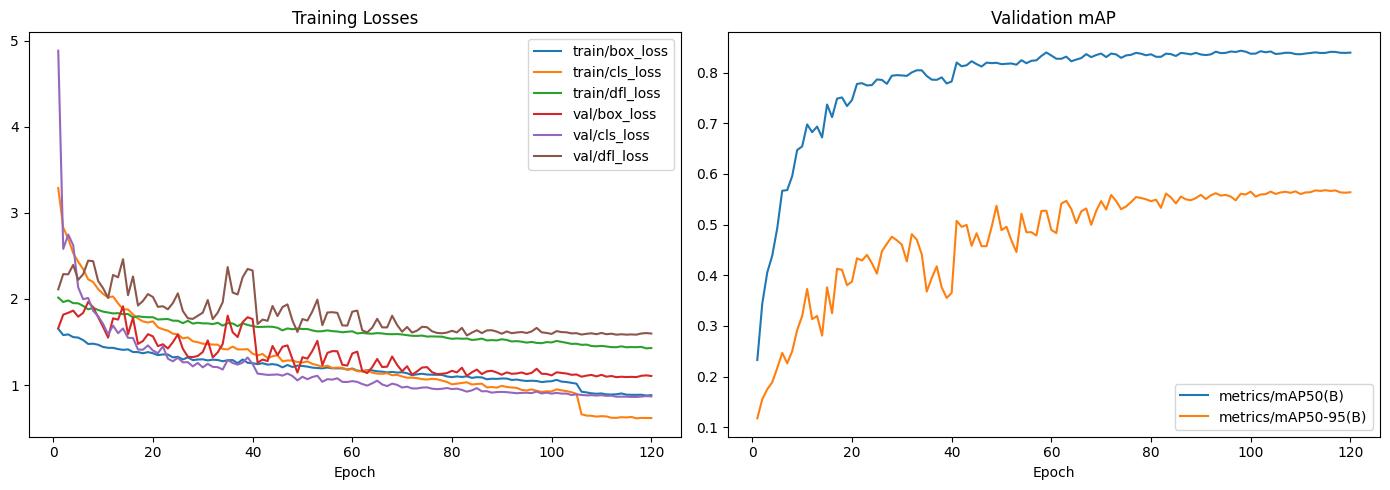

In [11]:
print('=' * 55)
print('RESULTS SUMMARY')
print('=' * 55)
print(f'Model:         YOLOv11x (pretrained COCO -> fine-tuned)')
print(f'Image size:    {IMGSZ}px')
print(f'Augmentations: mosaic, close_mosaic=15, copy_paste=0.3,')
print(f'               mixup=0.15, flipud=0.3, degrees=15')
print(f'Label smooth:  0.1')
print(f'Val split:     80/20 (честный)')
print(f'Inference:     TTA + FP16 + WBF postprocessing')
print(f'Seed:          {SEED}')
print(f'\nVal mAP@0.5:      {val_results.box.map50:.4f}')
print(f'Val mAP@0.5:0.95: {val_results.box.map:.4f}')
print(f'\nSubmission: sample_submission.csv')
print(f'Predictions: {df_result.PredictionString.notna().sum()} / {len(df_result)} images')

results_csv = RUN_DIR / 'yolo11x_det' / 'results.csv'
if results_csv.exists():
    df_tr = pd.read_csv(results_csv)
    df_tr.columns = df_tr.columns.str.strip()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for col in [c for c in df_tr.columns if 'loss' in c.lower()]:
        axes[0].plot(df_tr['epoch'], df_tr[col], label=col)
    axes[0].set_title('Training Losses'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    for col in [c for c in df_tr.columns if 'map' in c.lower()]:
        axes[1].plot(df_tr['epoch'], df_tr[col], label=col)
    axes[1].set_title('Validation mAP'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png', dpi=100)
    plt.show()